In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import simweights
import pickle
import os, sys
import re
import numpy as np

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import matplotlib as mat
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as colors
import pandas as pd
import tables
import h5py
import math
from scipy.stats import mstats
import matplotlib as mpl
import matplotlib.font_manager as font_manager


In [ ]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/notebooks/weighting")
from weights import *
from utils import *
from selections import selection_mask
from fonts import *
from plot_utils import *

In [9]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing")
from datasets.datasets_hese import hese_iceprod_v7
from datasets.datasets_spice import spice_tau_reco

In [11]:
simulation_datasets = {}

simulation_datasets["hese_iceprod_v7"] = hese_iceprod_v7.copy()
simulation_datasets["spice_tau_reco"] = spice_tau_reco.copy()

In [12]:
livetime_yr = 11.687
livetime_s  = livetime_yr * 365.25 * 24 * 3600 # 11.687 year

In [13]:
plotting_path = f"/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/self_veto/compare_spice_ftp"
os.system(f"mkdir -p {plotting_path}")

0

In [14]:
# weight functions
gamma_astro = 2.87
per_flavor_norm = 2.12
AstroFluxModel_HESE = create_AstroFluxModel(per_flavor_norm=per_flavor_norm, gamma_astro=gamma_astro)

In [16]:
def open_datasets( simulation_dataset, keys_to_merge ):

    # open the files
    for key in simulation_dataset:
        print(f"----- Extracting files for {key}")
        simulation_dataset[key]['hdf_file'] = pd.HDFStore(simulation_dataset[key]['hdf_file_path'],'r')
        if "Muon" in key: simulation_dataset[key]['weighter'] = None
        else: simulation_dataset[key]['weighter'] = simweights.NuGenWeighter( simulation_dataset[key]['hdf_file'] ,nfiles=simulation_dataset[key]['nfiles'])

    # merging files
    for new_key in keys_to_merge:
        print(f"----- Creating new key {new_key}")
        simulation_dataset[new_key] = {}
        simulation_dataset[new_key]['variables'] = {}
        simulation_dataset[new_key]['weighter'] = None

        for key in keys_to_merge[new_key]:
            
            print(f"Using {key}")
            # merge the weighters
            if simulation_dataset[new_key]['weighter'] == None:
                simulation_dataset[new_key]['weighter'] = simulation_dataset[key]['weighter']
            else: simulation_dataset[new_key]['weighter'] += simulation_dataset[key]['weighter']

    return simulation_dataset



In [17]:
keys_to_merge = {}

keys_to_merge["hese_iceprod_v7"] = {
    "NuE" : ["NuE_midE", "NuE_highE"],
    "NuMu" : ["NuMu_midE", "NuMu_highE"],
    "NuTau" : ["NuTau_midE", "NuTau_highE"],
    "NuAll" : ['NuE', "NuMu", "NuTau"],
}

keys_to_merge["spice_tau_reco"] = {
    "NuE" : ["NuE_midE1", "NuE_highE1", "NuE_midE2", "NuE_highE2"],
    "NuMu" : ["NuMu_midE1", "NuMu_highE1","NuMu_midE2", "NuMu_highE2"],
    "NuTau" : ["NuTau_midE1", "NuTau_highE1","NuTau_midE2", "NuTau_highE2"],
    "NuAll" : ['NuE', "NuMu", "NuTau"],

}



In [18]:
for key in simulation_datasets: simulation_datasets[key] = open_datasets( simulation_datasets[key], keys_to_merge[key] )

----- Extracting files for NuE_highE
----- Extracting files for NuE_midE
----- Extracting files for NuTau_midE
----- Extracting files for NuTau_highE
----- Extracting files for NuMu_highE
----- Extracting files for NuMu_midE
----- Creating new key NuE
Using NuE_midE
Using NuE_highE
----- Creating new key NuMu
Using NuMu_midE
Using NuMu_highE
----- Creating new key NuTau
Using NuTau_midE
Using NuTau_highE
----- Creating new key NuAll
Using NuE
Using NuMu
Using NuTau
----- Extracting files for NuTau_midE1
----- Extracting files for NuTau_highE1
----- Extracting files for NuTau_midE2
----- Extracting files for NuTau_highE2
----- Extracting files for NuE_midE1
----- Extracting files for NuE_highE1
----- Extracting files for NuE_midE2
----- Extracting files for NuE_highE2
----- Extracting files for NuMu_midE1
----- Extracting files for NuMu_highE1
----- Extracting files for NuMu_midE2
----- Extracting files for NuMu_highE2
----- Creating new key NuE
Using NuE_midE1
Using NuE_highE1
Using Nu

In [19]:
dataset_label_dict = {
    "hese_iceprod_v7" : "FTP",
    "spice_tau_reco" : "Spice",
}

check if merging works now, seems to be fine

In [20]:
data = {}

for key in simulation_datasets:

    simulation_dataset = simulation_datasets[key]

    channel_data = {}

    for flavor in ['NuE', "NuMu", "NuTau"]:
        weights = simulation_dataset[flavor]["weighter"].get_weights(AstroFluxModel_HESE) * livetime_s
        rate = np.sum(weights)
        error = np.sqrt(np.sum(weights**2))
        channel_data[f"astro_{flavor}"] = f"{rate:.2f} ± {error:.2f}"

    # Conventional
    flavor = "NuAll"
    weights_conv = simulation_dataset[flavor]["weighter"].get_weights(generator_conv) * livetime_s
    rate_conv = np.sum(weights_conv)
    err_conv = np.sqrt(np.sum(weights_conv**2))
    channel_data["conv"] = f"{rate_conv:.3f} ± {err_conv:.3f}"

    # Prompt
    weights_prompt = simulation_dataset[flavor]["weighter"].get_weights(generator_pr) * livetime_s
    rate_prompt = np.sum(weights_prompt)
    err_prompt = np.sqrt(np.sum(weights_prompt**2))
    channel_data["prompt"] = f"{rate_prompt:.2f} ± {err_prompt:.2f}"

    data[ dataset_label_dict[key] ] = channel_data

# Create DataFrame
df = pd.DataFrame.from_dict(data, orient='index')

# Optional: specify column order
columns_order = [f"astro_{flavor}" for flavor in ['NuE', 'NuMu', 'NuTau']] + ["conv", "prompt"]
df = df[columns_order]

# Display as string table
print(df.to_string())

          astro_NuE    astro_NuMu   astro_NuTau            conv        prompt
FTP    56.74 ± 0.37  20.58 ± 0.15  35.05 ± 0.28  41.469 ± 0.730  13.43 ± 0.07
Spice  56.77 ± 0.56  20.42 ± 0.22  34.89 ± 0.43  38.766 ± 0.947  13.41 ± 0.11


In [22]:
def compare_dataset_flavor( base_key = "spice_tau_reco",
                            base_var_key1 = "I3MCWeightDict", 
                            base_var_key2 = "PrimaryNeutrinoEnergy",
                            alt_key = "hese_iceprod_v7",
                            alt_var_key1 = "I3MCWeightDict", 
                            alt_var_key2 = "PrimaryNeutrinoEnergy",
                            variable_name = "PrimaryNeutrinoEnergy [GeV]",
                            bins = np.geomspace(1e4, 1e6, 20),
                            xscale = "log", yscale = "log",
                            savename = "PrimaryNeutrinoEnergy"):


    # Compute bin centers for plotting
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Create 2 rows × 3 columns layout: top row = histograms, bottom row = ratios
    fig = plt.figure(figsize=(18, 8))  # Adjust height as needed
    gs = GridSpec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    fig.suptitle(rf"Variable {variable_name}", fontsize=16)

    # Create 3 upper and 3 lower subplots
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]        # ax0, ax1, ax2
    axes_ratio = [fig.add_subplot(gs[1, i], sharex=axes[i]) for i in range(3)]  # ax0_ratio, etc.

    # Now iterate over axes
    for ax, ax_ratio, flavor in zip(axes, axes_ratio, ["NuE", "NuMu", "NuTau"]):
        ax.set_title(rf"{flavor} astro, $\gamma = 2.87$, $\phi_0=2.12$, HESE")
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.set_ylabel(f"Rate / {livetime_yr} yr") 

        ax_ratio.set_xscale(xscale)
        ax_ratio.set_ylabel(f"Ratio { dataset_label_dict[alt_key]}" + "\n" + f"{dataset_label_dict[base_key]}")
        ax_ratio.set_xlabel(variable_name)
        ax_ratio.axhline(1, color="gray", linestyle="--", linewidth=1)

        var1 = simulation_datasets[base_key][flavor]["weighter"].get_column(base_var_key1, base_var_key2)
        var2 = simulation_datasets[alt_key][flavor]["weighter"].get_column(alt_var_key1, alt_var_key2)

        weights1 = simulation_datasets[base_key][flavor]["weighter"].get_weights(AstroFluxModel_HESE) * livetime_s
        weights2 = simulation_datasets[alt_key][flavor]["weighter"].get_weights(AstroFluxModel_HESE) * livetime_s

        # Compute histograms
        hist1, _  = np.histogram(var1,weights=weights1,bins=bins )
        hist2, _  = np.histogram(var2,weights=weights2,bins=bins )

        # compute errors
        hist1_error, _ = error_cal(bin_edges=bins,weights=weights1, data=var1)
        hist2_error, _ = error_cal(bin_edges=bins,weights=weights2, data=var2)

        # Compute ratios
        ratio = hist2 / hist1

        ax_ratio.plot(bin_centers, ratio, drawstyle="steps-mid", color="black")

        # Upper plot: histograms
        ax.hist(var1, 
                weights=weights1, 
                bins=bins, histtype="step", color="black", linestyle="-",label =  dataset_label_dict[base_key])
        ax.hist(var2, 
                weights=weights2, 
                bins=bins, histtype="step", color="C3", linestyle="-",label =  dataset_label_dict[alt_key])

        # Plot the error band
        ax.errorbar(x=bin_centers, y=hist1,yerr=hist1_error, color="black",fmt='o', markersize=2,capsize=5)
        ax.errorbar(x=bin_centers, y=hist2,yerr=hist2_error, color="C3",fmt='o', markersize=2,capsize=5)
        # ax.fill_between(bin_centers, hist2 - hist2_error, hist2 + hist2_error,step="mid", alpha=0.4, color="C3")

        # error of the ratio
        ratio_error = ratio * np.sqrt(
                (hist1_error / hist1)**2 + (hist2_error / hist2)**2
        )
        ratio_error[~np.isfinite(ratio_error)] = 0  # Set ratio error to 0 where hist1 or hist2 is 0
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_error,fmt='o', color='black', markersize=2, capsize=5)

        # Improve layout
        plt.setp(ax.get_xticklabels(), visible=False)
        ax_ratio.set_ylim(0.5, 1.5)  # adjust as needed
        ax_ratio.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.set_xlim(bins[0], bins[-1])

        ax.legend()

    plt.savefig(f"{plotting_path}/{savename}_flavor.pdf")

    plt.show()

Lets make some plots! 

First the true variables.

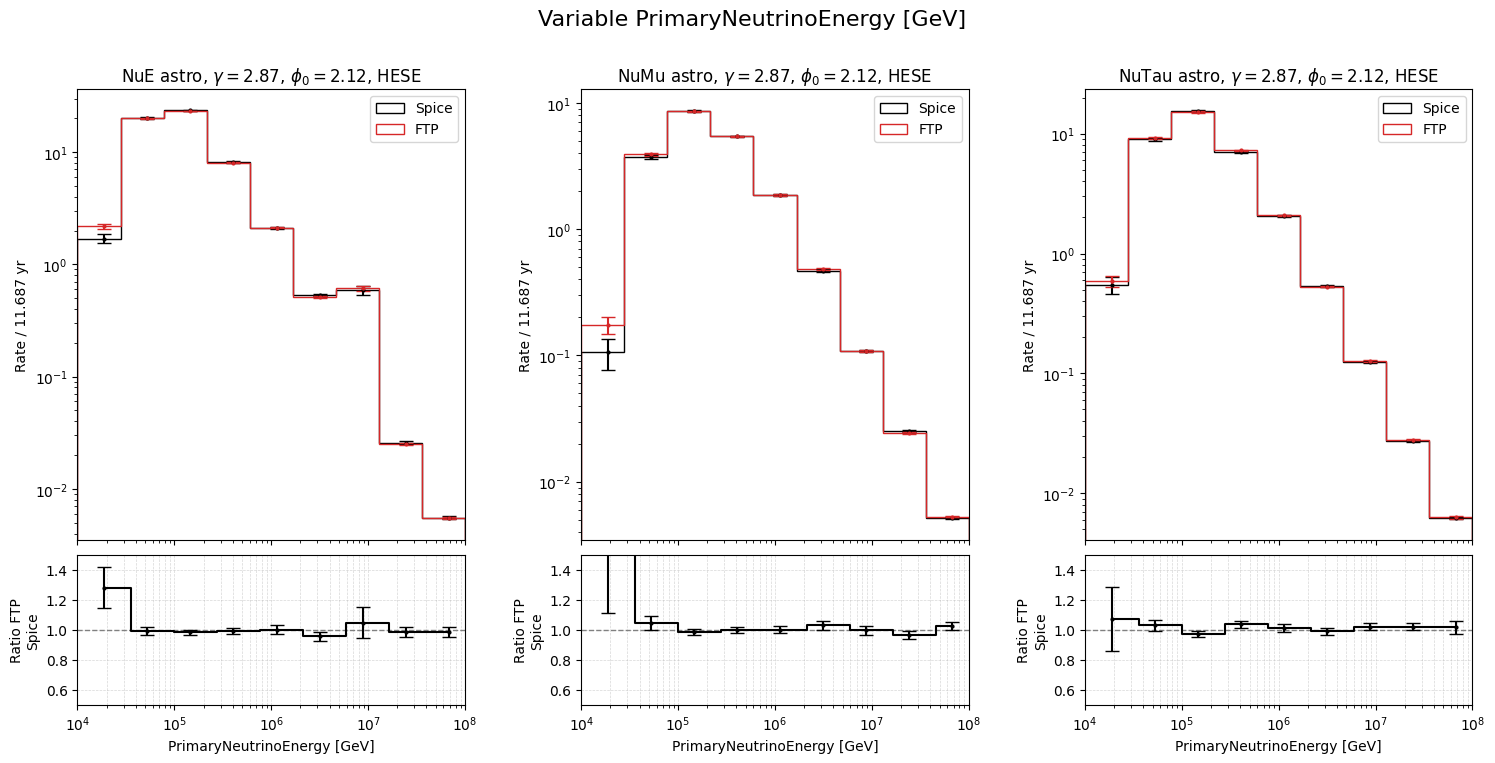

In [23]:
compare_dataset_flavor( base_key = "spice_tau_reco", base_var_key1 = "I3MCWeightDict", base_var_key2 = "PrimaryNeutrinoEnergy",
                        alt_key  = "hese_iceprod_v7", alt_var_key1 = "I3MCWeightDict", alt_var_key2 = "PrimaryNeutrinoEnergy",
                        variable_name = "PrimaryNeutrinoEnergy [GeV]", bins = np.geomspace(1e4, 1e8, 10), xscale = "log", yscale = "log", savename="PrimaryNeutrinoEnergy" )


Lets start with the penetrating depth

/tmp/ipykernel_3921914/872791980.py:53: RuntimeWarning: invalid value encountered in divide
  ratio = hist2 / hist1
/tmp/ipykernel_3921914/872791980.py:72: RuntimeWarning: invalid value encountered in divide
  (hist1_error / hist1)**2 + (hist2_error / hist2)**2


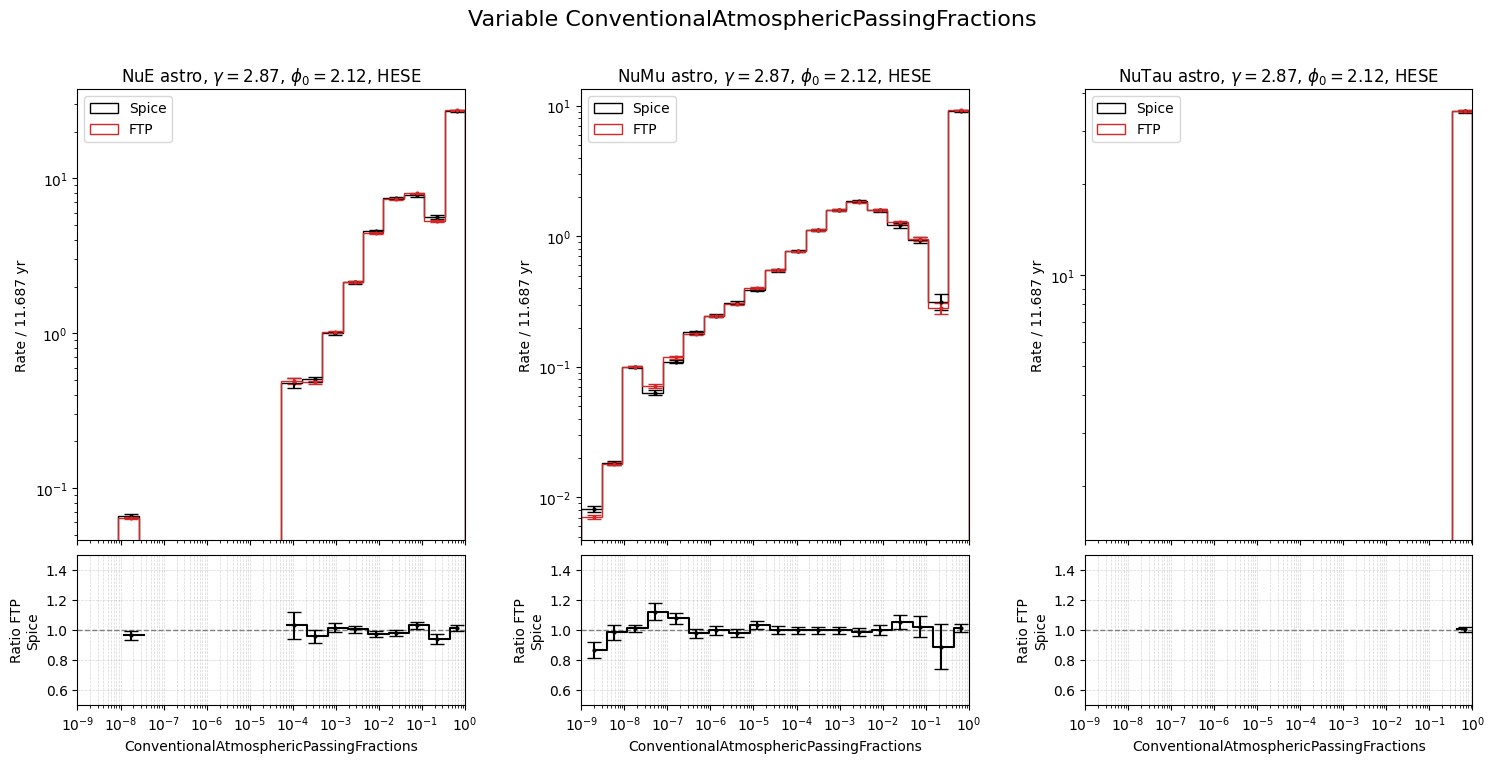

In [48]:
compare_dataset_flavor( base_key = "spice_tau_reco", base_var_key1 = "ConventionalAtmosphericPassingFractions", base_var_key2 = "value",
                        alt_key  = "hese_iceprod_v7", alt_var_key1 = "ConventionalAtmosphericPassingFractions", alt_var_key2 = "value",
                        variable_name = "ConventionalAtmosphericPassingFractions", bins = np.geomspace(1e-9, 1e0, 20), xscale = "log", yscale = "log", savename="ConventionalAtmosphericPassingFractions" )

/tmp/ipykernel_3921914/872791980.py:53: RuntimeWarning: invalid value encountered in divide
  ratio = hist2 / hist1
/tmp/ipykernel_3921914/872791980.py:72: RuntimeWarning: invalid value encountered in divide
  (hist1_error / hist1)**2 + (hist2_error / hist2)**2


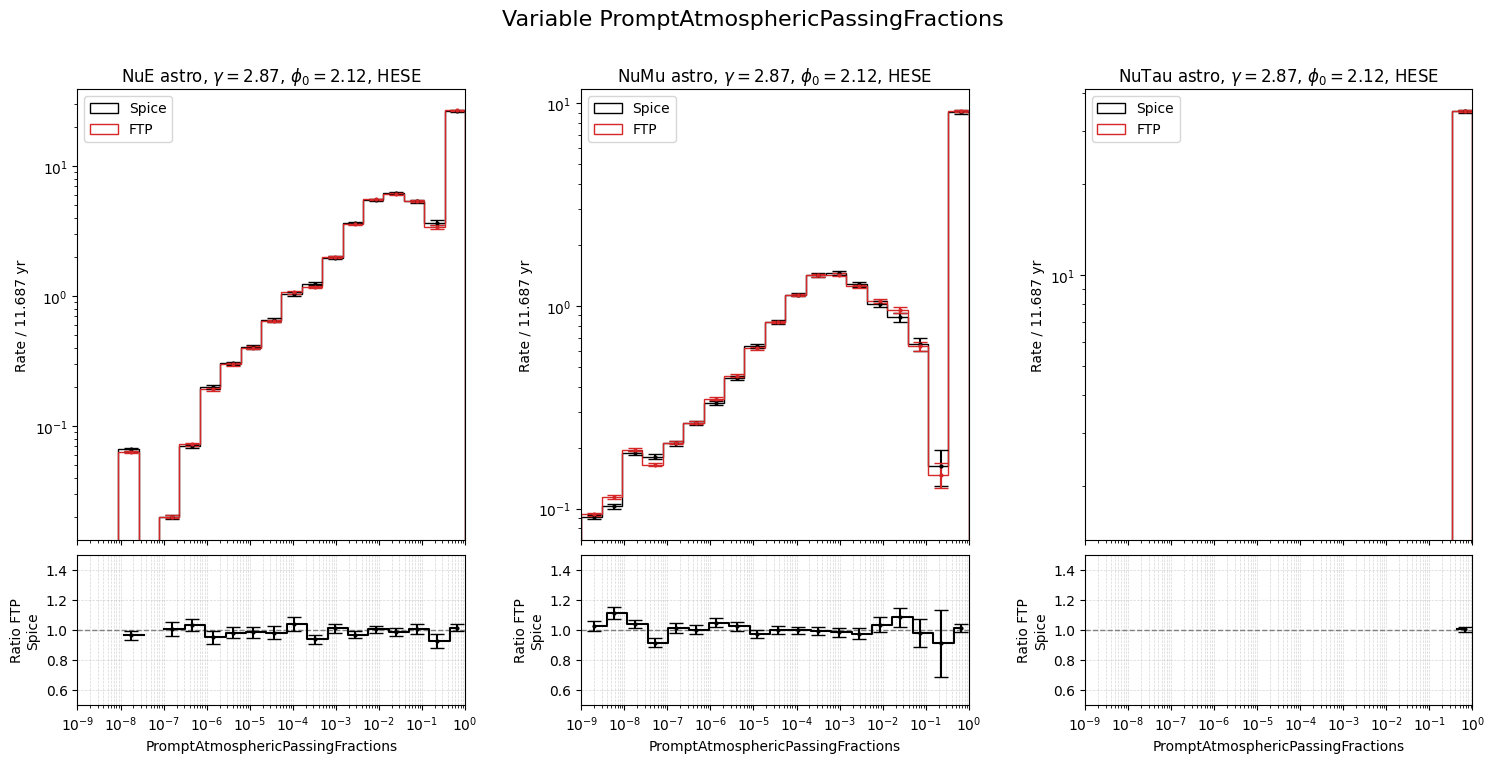

In [49]:
compare_dataset_flavor( base_key = "spice_tau_reco", base_var_key1 = "PromptAtmosphericPassingFractions", base_var_key2 = "value",
                        alt_key  = "hese_iceprod_v7", alt_var_key1 = "PromptAtmosphericPassingFractions", alt_var_key2 = "value",
                        variable_name = "PromptAtmosphericPassingFractions", bins = np.geomspace(1e-9, 1e0, 20), xscale = "log", yscale = "log", savename="PromptAtmosphericPassingFractions" )

In [ ]:
def scatter_dataset_flavor(
    dataset_key="spice_tau_reco",
    var_key1_1="I3MCWeightDict",
    var_key1_2="PrimaryNeutrinoEnergy",
    var_key2_1="I3MCWeightDict",
    var_key2_2="SomeOtherVariable",
    xlabel="PrimaryNeutrinoEnergy [GeV]",
    ylabel="SomeOtherVariable",
    savename=None,
    xscale="log",
    yscale="log"
):

    flavors = ["NuE", "NuMu", "NuTau"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f"{xlabel} vs {ylabel} ({dataset_label_dict[dataset_key]})", fontsize=16)

    for ax, flavor in zip(axes, flavors):

        ax.set_title(flavor)
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.set_xlabel(xlabel)

        if ax == axes[0]:
            ax.set_ylabel(ylabel)

        # Get variables
        var1 = simulation_datasets[dataset_key][flavor]["weighter"].get_column(
            var_key1_1, var_key1_2
        )
        var2 = simulation_datasets[dataset_key][flavor]["weighter"].get_column(
            var_key2_1, var_key2_2
        )

        # Optional: weights (for coloring or size)
        weights = simulation_datasets[dataset_key][flavor]["weighter"].get_weights(
            AstroFluxModel_HESE
        ) * livetime_s

        # Scatter plot
        sc = ax.scatter(
            var1,
            var2,
            c=weights,          # color by weights
            s=5,
            alpha=0.5,
            norm=None
        )

        ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    if savename: plt.savefig(f"{plotting_path}/{savename}_scatter_flavor.pdf")
    plt.show()

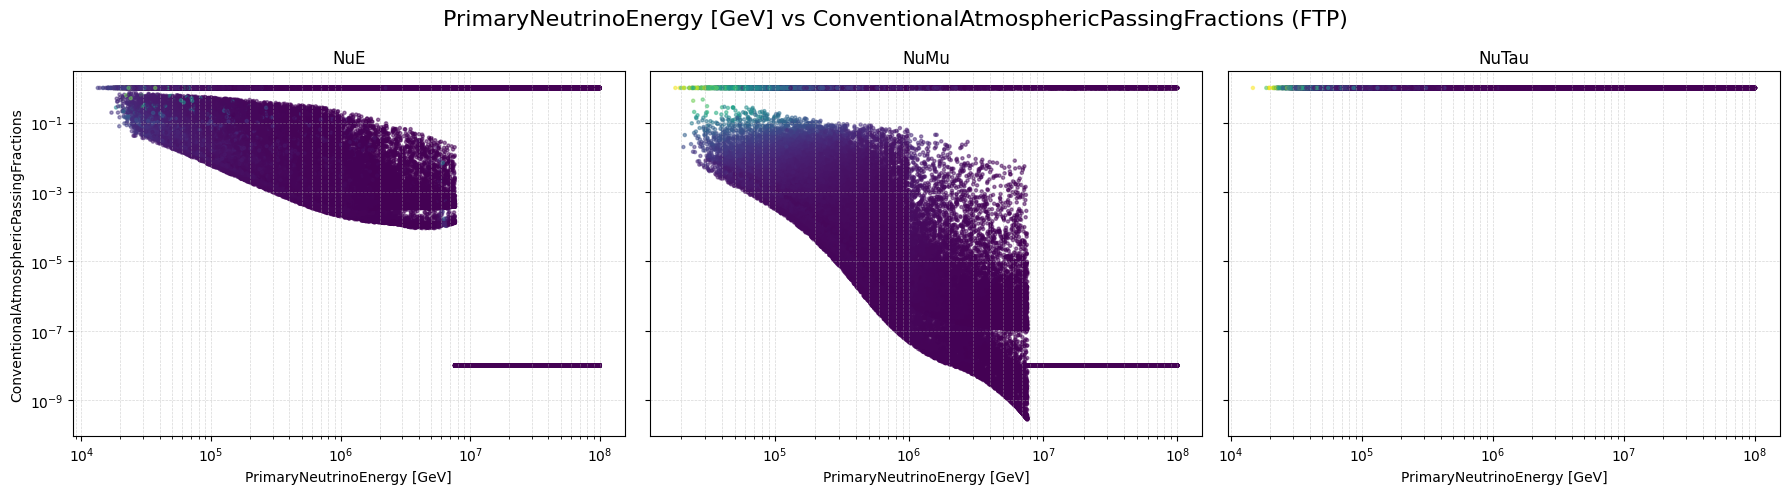

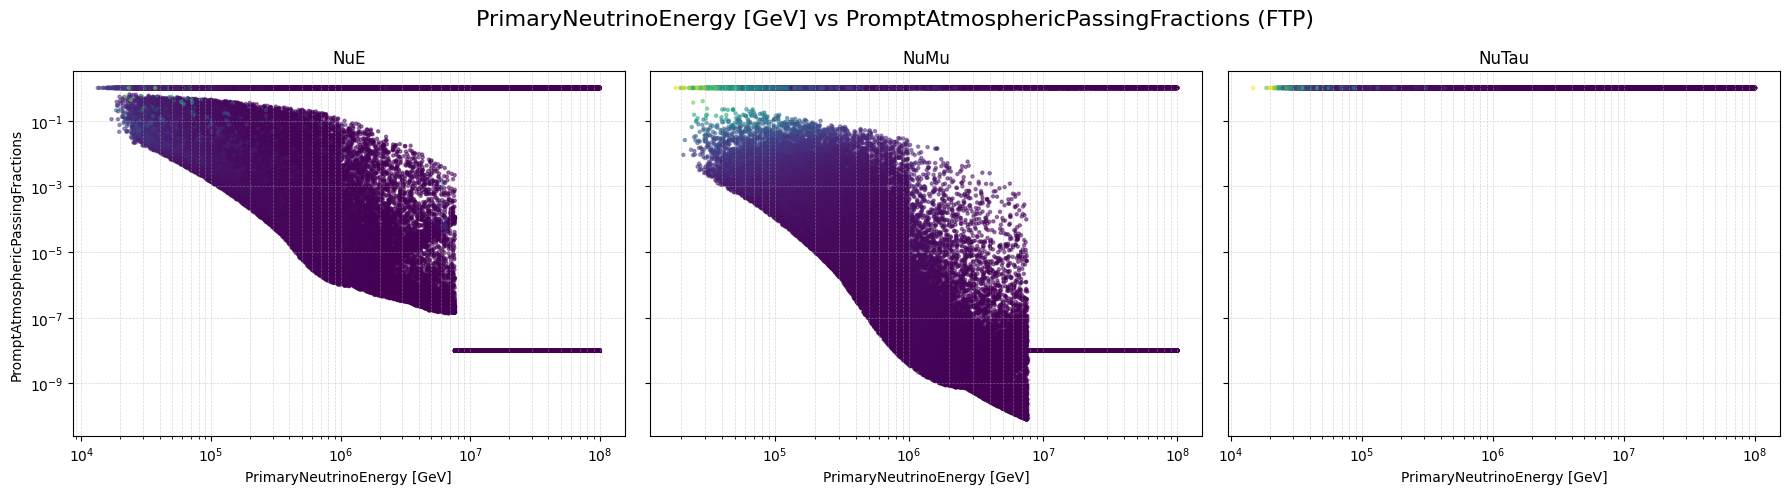

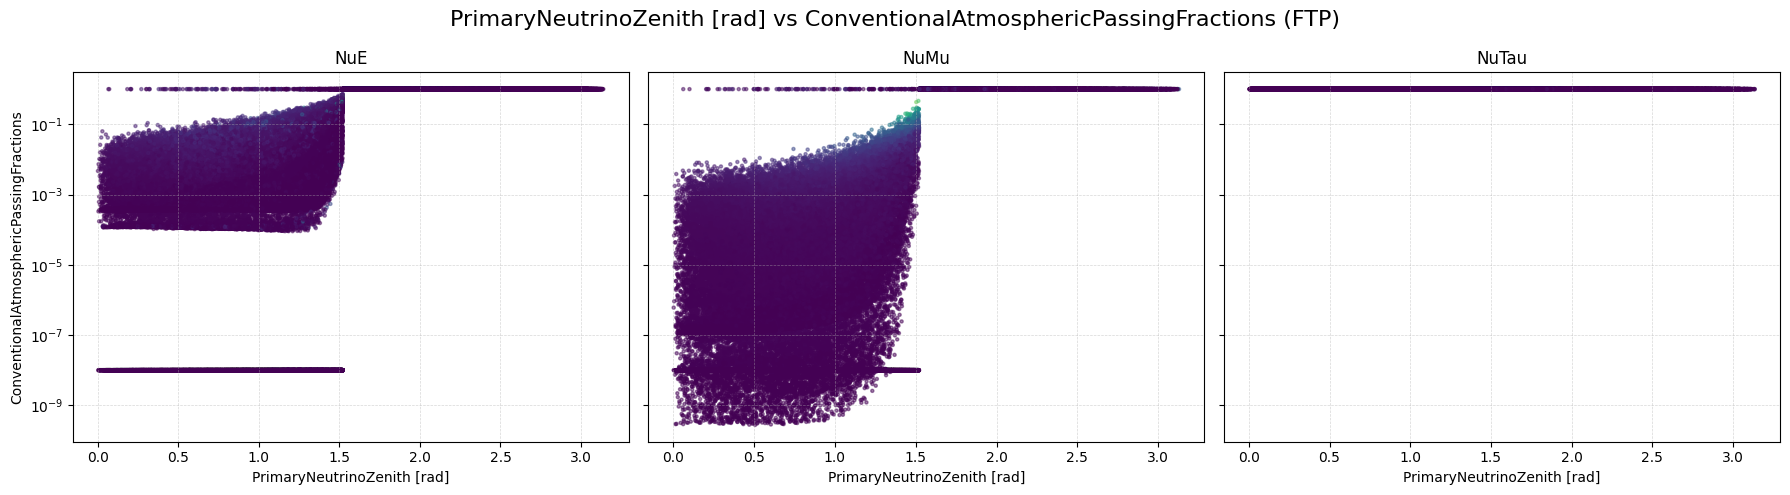

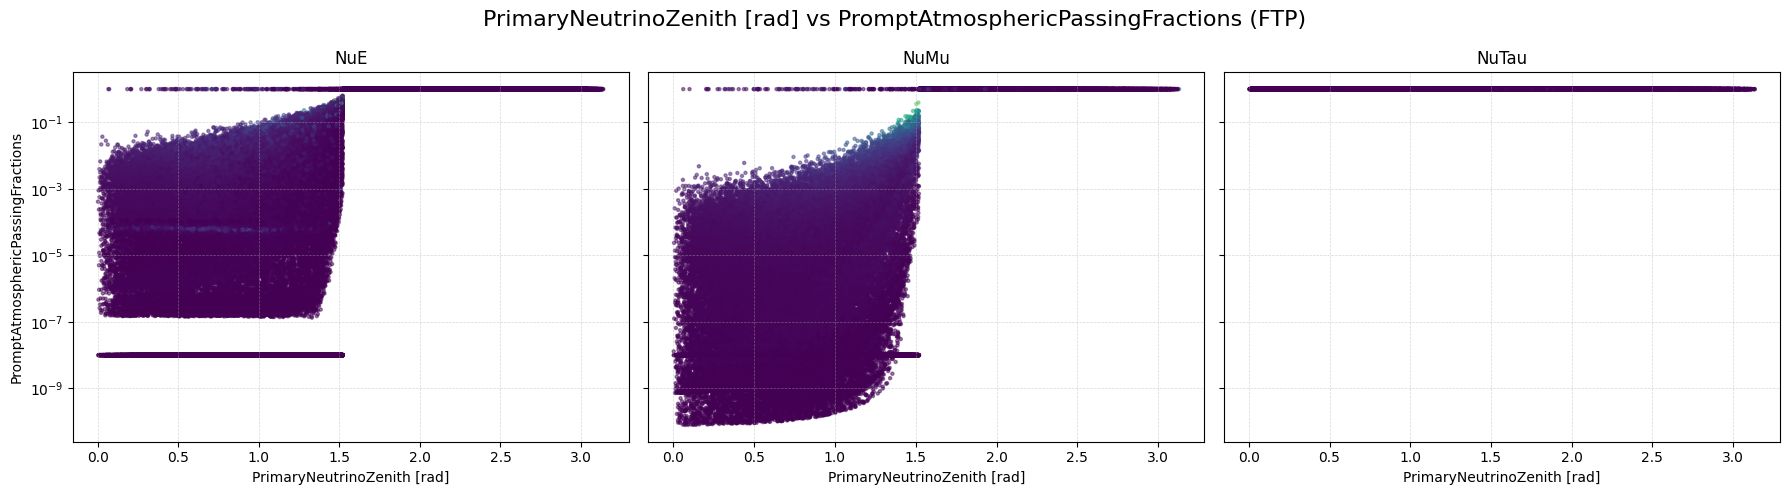

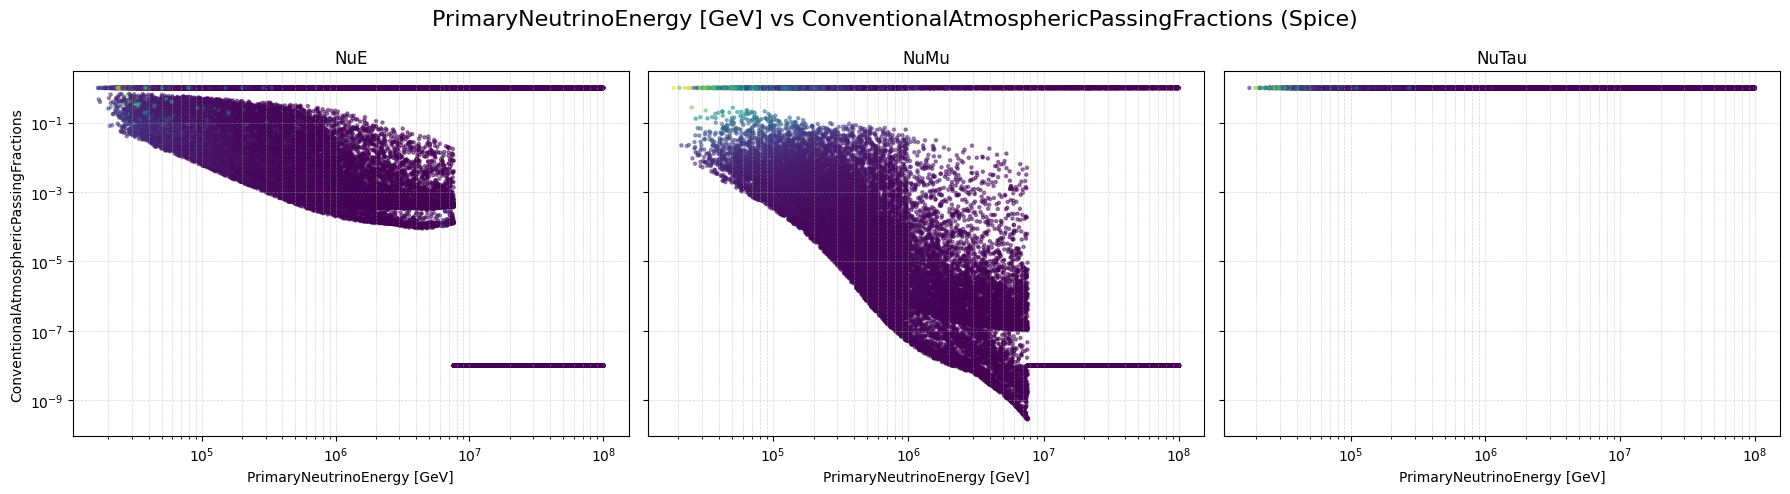

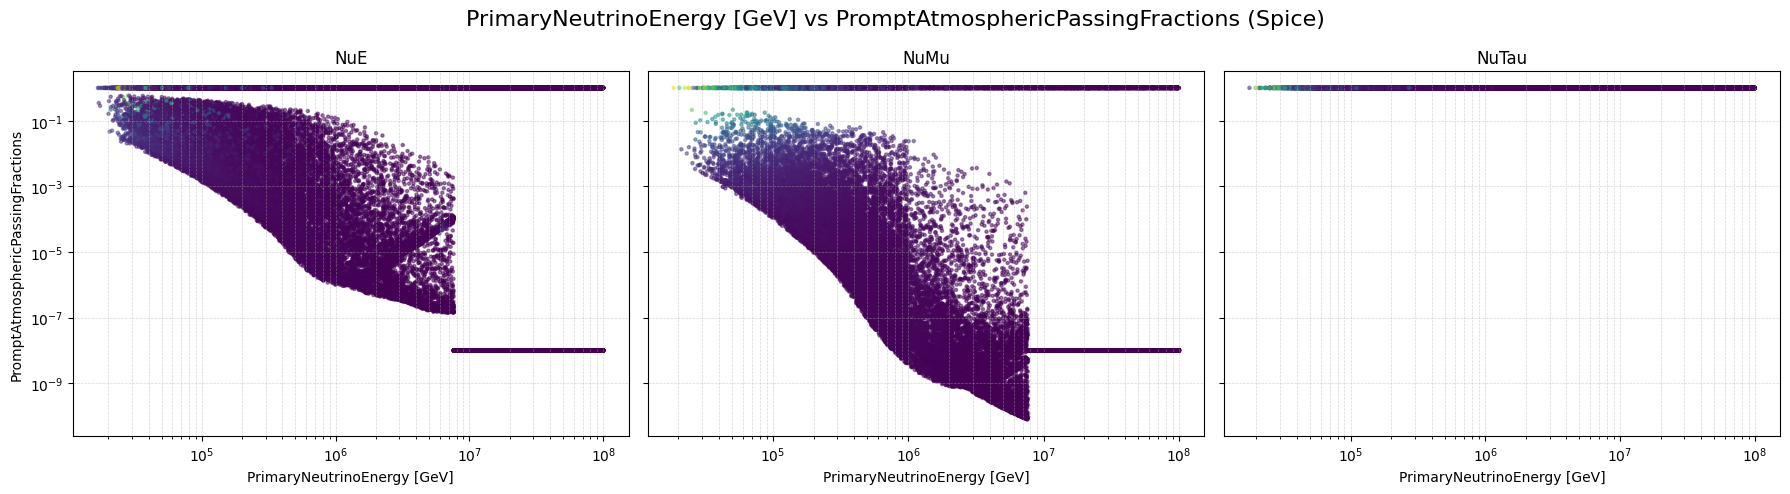

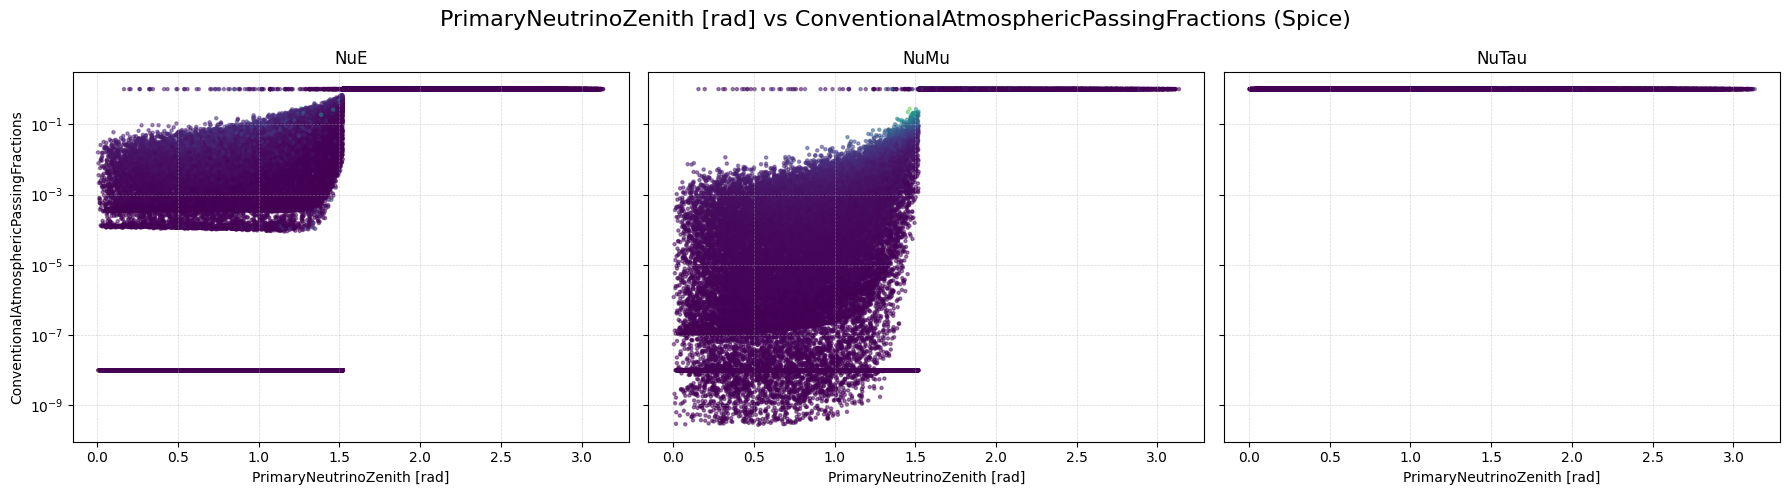

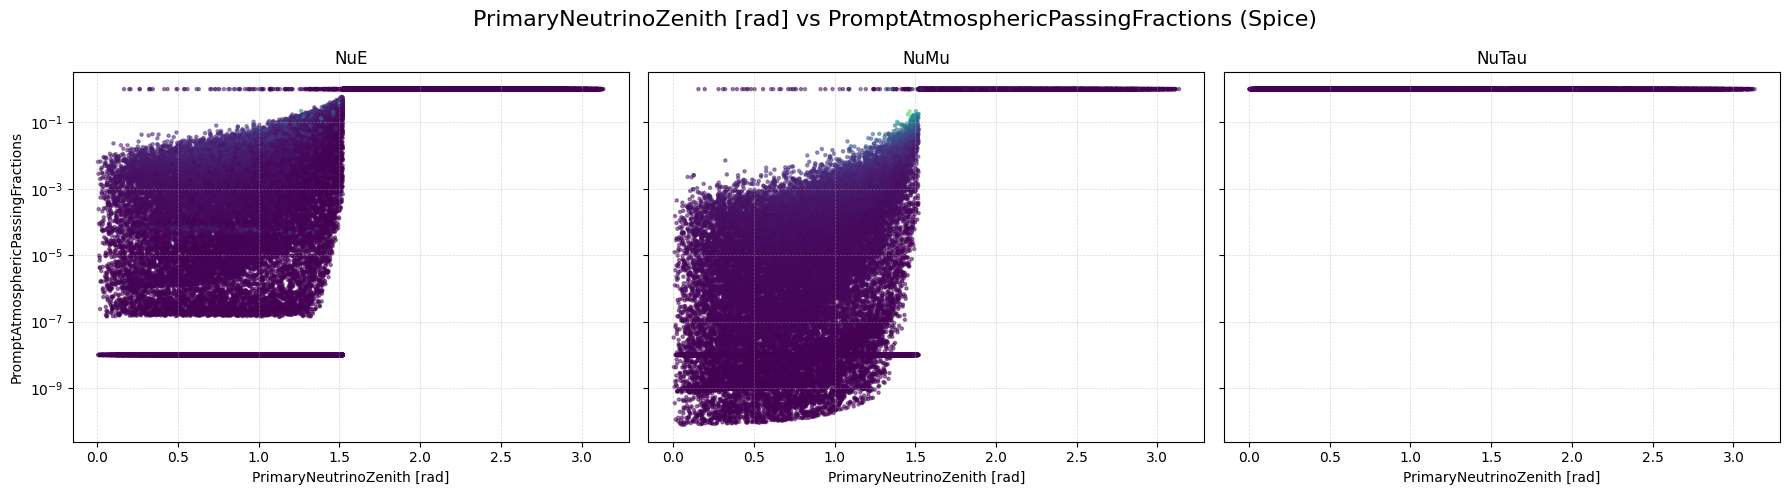

In [63]:
for dataset_key in simulation_datasets.keys():
    for var_x,xscale,xlabel in zip(["PrimaryNeutrinoEnergy","PrimaryNeutrinoZenith"],
                                   ["log","linear"],
                                   ["PrimaryNeutrinoEnergy [GeV]", "PrimaryNeutrinoZenith [rad]"]):
        for var_y in ["ConventionalAtmosphericPassingFractions","PromptAtmosphericPassingFractions"]:
            scatter_dataset_flavor(
            dataset_key=dataset_key,
            var_key1_1="I3MCWeightDict",
            var_key1_2=var_x,
            var_key2_1=var_y,
            var_key2_2="value",
            xlabel=xlabel,
            ylabel=var_y,
            savename=f"{dataset_key}_{var_x}-{var_y}",
            xscale=xscale,
            yscale="log"
        )